In [163]:
import numpy as np
import commpy as cp
import matplotlib.pyplot as plt

In [164]:
modulation_size = 16

modem = cp.QAMModem(modulation_size)

Модулированные символы:
$$
I= \{I_i \}_{i=0}^{N-1};
$$

Импульсная характеристика многолучевого канала:
$$
h=\{h_i \}_{i=0}^{L-1};
$$

Сигнал на выходе из канала:
$$\nu = h * I + n \quad \Longleftrightarrow \quad \nu_k = \sum\limits_{i=0}^{L-1}h_i \cdot I_{k-i} + n_k. \quad (k - i \geq 0)$$

Запускаем сигнал на фильтр прямой связи (**Feed-Forward Filter**):
$$
f = w^{ff} * \nu \quad \Longleftrightarrow \quad f_k = \sum\limits_{i=0}^{K_1-1}w^{ff}_i \cdot \nu_{k-i}, \quad (k - i \geq 0)
$$
где $w^{ff}$ - веса фильтра прямой связи, длина фильтра $K_1$.
Для определения фильтра с обратной связью по решению, рассмотрим поподробнее сигнал на выходе из фильтра прямой связи:
$$
\begin{aligned}
    f_k = \sum\limits_{i=0}^{K_1-1}w^{ff}_i \cdot \nu_{k-i} = \sum\limits_{i=0}^{K_1-1}w^{ff}_i \cdot (\sum\limits_{l=0}^{L-1}h_l \cdot I_{k-i-l} + n_{k-i})&= w^{ff}_0h_0I_k + w^{ff}_0h_1I_{k-1} + w^{ff}_0h_2I_{k-2} + \ldots + \\
    &+w^{ff}_1h_0I_{k-1} + w^{ff}_1h_1I_{k-2} + w^{ff}_1h_2I_{k-3} + \ldots + \\
    &+w^{ff}_2h_0I_{k-2} + w^{ff}_2h_1I_{k-3} + w^{ff}_2h_2I_{k-4} + \ldots + \\
    &+ \ldots + \\
    &+\sum\limits_{i=0}^{K_1-1}w^{ff}_i \cdot n_{k-i} = \\
    &= w^{ff}_0h_0I_k + (w^{ff}_0h_1 + w^{ff}_1h_0)\cdot I_{k-1} + \\
    &+ (w^{ff}_0h_2 + w^{ff}_1h_1 + w^{ff}_2h_0) \cdot I_{k-2} + \\
    &+ (w^{ff}_0h_3 + w^{ff}_1h_2 + w^{ff}_2h_1 + w^{ff}_3h_0) \cdot I_{k-3} + \\
    &+\ldots+ \\
    &+\sum\limits_{i=0}^{K_1-1}w^{ff}_i \cdot n_{k-i} = \\
    &=\sum_{i=0}^{(K_1-1) + (L-1)}I_{k-i}\sum_{l=0}^i w^{ff}_lh_{i-l} + \sum_{i=0}^{K_1-1}w^{ff}_i \cdot n_{k-i} \quad (l \leq K_1 - 1; \ i-l \leq L-1)
\end{aligned}
$$

Чтобы убрать посткурсоры, понадобится фильтр обратной связи по решению (**Feed-Back Filter**):
$$
b = w^{fb} * \hat{I} \Longleftrightarrow b_k = \sum_{i=0}^{K_2 - 1} w_i^{fb}\hat{I}_{(k-K_1+1) - (i + 1)}
$$
где $\hat{I}_{(k-K_1+1) - (i + 1)}$ - ранее продетектированные символы. Получаем:
$$
y_k = f_k - b_k = \sum_{i=0}^{(K_1 - 1) + (L - 1)}I_{k-i}\sum_{l=0}^{i}w_l^{ff}h_{i-l} + \sum_{i=0}^{K_1-1}w_i^{ff}n_{k-i} - \sum_{i=0}^{K_2 - 1} w_i^{fb}\hat{I}_{(k-K_1+1) - (i + 1)}
$$
Получаем:
$$
y_k = \sum_{i=0}^{K_1 - 1}I_{k-i}\sum_{l=0}^{i}w_l^{ff}h_{i-l} + \sum_{i=K_1}^{(K_1-1) + (L - 1)}I_{k-i}\sum_{l=0}^{i}w_l^{ff}h_{i-l} - \sum_{i=0}^{K_2 - 1} w_i^{fb}\hat{I}_{(k-D+1) - (i + 1)} + \sum_{i=0}^{K_1-1}w_i^{ff}n_{k-i}
$$
Пусть:
$$
g_i = \sum_{l=0}^{i}w_l^{ff}h_{i-l}
$$
Тогда действие фильтра обратной связи по решению можно переписать следующим образом:
$$
\sum_{i=K_1}^{(K_1 - 1) + (L - 1)}I_{k-i}g_i - \sum_{i=0}^{K_2 - 1} w_i^{fb}\hat{I}_{(k-K_1+1) - (i + 1)} = \sum_{i=0}^{L - 2}I_{k-(i+K_1)}g_{K_1 + i} - \sum_{i=0}^{K_2 - 1} w_i^{fb}\hat{I}_{(k-K_1+1) - (i + 1)} =
\sum_{i=0}^{L - 2}I_{k-(i+K_1)}g_{K_1 + i} - \sum_{i=0}^{K_2 - 1} w_i^{fb}\hat{I}_{k - (i+K_1)}
$$
Откуда следует:
$$
K_2 = L - 1; \quad w_i^{fb} = g_{K_1 + i} = \sum_{l=0}^{K_1 + i}w_l^{ff}h_{K_1 + i-l} \quad (l \leq K_1 - 1; \ i \leq K_1-2)
$$

При условии правильности ранее продетектированных символов, получаем:
$$
y_k = \sum_{i=0}^{K_1 - 1}I_{k-i}\sum_{l=0}^{i}w_l^{ff}h_{i-l} + \sum_{i=0}^{K_1-1}w_i^{ff}n_{k-i}
$$
Для определения длины фильтра прямой связи, рассмотрим случай $i=K_1-1$:
$$
I_{k - (K_1-1)} (w_0^{ff}h_{K_1-1} + \ldots + w_{K_1-1}^{ff}h_0)
$$
Отсюда видно, что если взять $K_1 < L$, то мы получим не всю информацию о канале, при $K_1>L$, мы получаем избыточную информацию. Для начала, возьмём минимально возможную длину $K_1=L$.

Введём такое понятие как задержка символа величиной $D - 1$:
$$
\hat{I}_{k-D+1} \Longleftrightarrow y_k
$$

С учётом прошлый размышлений, полную информацию о канале на $y_k$ пришедшем символе будет нести символ $I_{k - (L-1)}$, откуда можно получить оптимальную задержку определения символа $D=L$. Также из прошлых размышлений следует $D=L=K_1=K_2+1$.

Разобрались с длинами фильтров. Осталось определить веса фильтра прямой связи и задача будет решена. Для этого введём функцию стоимости ошибки **MSE**:
$$
J = \mathbb{E} [|I_{k-D+1} - y_k|^2]
$$
Условие минимума данной функции **MMSE**:
$$
\nabla J = \frac{\partial J}{\partial \vec{w}^{ff}} = 0
$$
Распишем $J$:
$$
J = \mathbb{E}[|I_{k-D+1} - \sum_{i=0}^{D - 1}I_{k-i}g_i + \tilde{n}_k|^2].
$$
Из условия некоррелированности исходных символов:
$$
J = \sum_{i=0}^{D-2}|I_{k-i}|^2|g_i|^2 + |I_{k-D+1}|^2 \cdot |1-g_{D-1}|^2 + \mathbb{E}[|\tilde{n}_k|^2] =
$$

$$
= \sigma^2_I\sum_{i=0}^{D-2}|g_i|^2 + \sigma^2_I|1-g_{D-1}|^2 + \sigma^2_n\sum_{i=0}^{D-1}|w_i^{ff}|^2
$$
С учётом нормировки исходных символов: $\sigma^2_I = 1$:
$$
J = \sum_{i=0}^{D-2}|\sum_{m=0}^iw_m^{ff}h_{i-m}|^2 + |1-\sum_{m=0}^{D-1}w_m^{ff}h_{D-1-m}|^2 + \sigma^2_n\sum_{i=0}^{D-1}|w_i^{ff}|^2
$$
Найдём $n$-ую производную функции стоимости $J$:
$$
\frac{\partial J}{\partial w_n^{ff}} = 2\sum_{i=n}^{D-2}(\sum_{m=0}^iw_m^{ff}h_{i-m})h_{i-n} + 2(1-\sum_{m=0}^{D-1}w_m^{ff}h_{D-1-m})(-h_{D-1-n}) + 2\sigma^2_nw_n^{ff} = 0
$$
Раскрыв скобки, получаем:
$$
\sum_{i=n}^{D-2}(\sum_{m=0}^iw_m^{ff}h_{i-m})h_{i-n} + h_{D-1-n}\sum_{m=0}^{D-1}w_m^{ff}h_{D-1-m} + \sigma^2_nw_n^{ff} = h_{D-1-n}
$$
Рассмотрим первую сумму:
$$
\begin{aligned}
\sum_{i=n}^{D-2}(\sum_{m=0}^iw_m^{ff}h_{i-m})h_{i-n} &=\sum_{m=0}^nw_m^{ff}h_{n-m}h_0 \\
&+\sum_{m=0}^nw_m^{ff}h_{n+1-m}h_1 + w_{n+1}^{ff}h_0h_1 +\\
&+\sum_{m=0}^nw_m^{ff}h_{n+2-m}h_2 + w_{n+1}^{ff}h_1h_2 + w_{n+2}^{ff}h_0h_2 +\\
& \ldots \\
&+\sum_{m=0}^nw_m^{ff}h_{D-2-m}h_{D-2-n} + w_{n+1}^{ff}h_{D-2-(n+1)}h_{D-2-n} + w_{n+2}^{ff}h_{D-2-(n+2)}h_{D-2-n} + \ldots = \\
&=\sum_{m=0}^nw_m^{ff}\left( \sum_{i=n}^{D-2}h_{i-m}h_{i-n} \right) + \sum_{m=n+1}^{D-2}w_m^{ff}\left( \sum_{i=m}^{D-2}h_{i-m}h_{i-n} \right)
\end{aligned}
$$
При учёте второй суммы:
$$
\sum_{m=0}^nw_m^{ff}\left( \sum_{i=n}^{D-2}h_{i-m}h_{i-n} \right) + \sum_{m=n+1}^{D-2}w_m^{ff}\left( \sum_{i=m}^{D-2}h_{i-m}h_{i-n} \right) + h_{D-1-n}\sum_{m=0}^{D-1}w_m^{ff}h_{D-1-m} =
$$

$$
\sum_{m=0}^nw_m^{ff}\left( \sum_{i=n}^{D-2}h_{i-m}h_{i-n} \right) + \sum_{m=0}^{n}w_m^{ff}h_{D-1-m}h_{D-1-n} + \sum_{m=n+1}^{D-2}w_m^{ff}\left( \sum_{i=m}^{D-2}h_{i-m}h_{i-n} \right) + \sum_{m=n+1}^{D-1}w_m^{ff}h_{D-1-m}h_{D-1-n} =
$$

$$
=\sum_{m=0}^nw_m^{ff}\left( \sum_{i=n}^{D-1}h_{i-m}h_{i-n} \right) + \sum_{m=n+1}^{D-1}w_m^{ff}\left( \sum_{i=m}^{D-1}h_{i-m}h_{i-n} \right)
$$
В итоге получаем:
$$
\sum_{m=0}^nw_m^{ff}\left( \sigma^2_n \delta_{mn} + \sum_{i=n}^{D-1}h_{i-m}h_{i-n} \right) + \sum_{m=n+1}^{D-1}w_m^{ff}\left( \sum_{i=m}^{D-1}h_{i-m}h_{i-n} \right) = h_{D-1-n}
$$


Собираем получившуюся СЛАУ в матричное уравнение:
$$
(\mathbf{R} + \sigma^2_n \mathbf{I}) \cdot \vec{w}^{ff} = \vec{p}
$$
Разберём её составляющие по порядку:
$$
\mathbf{R} = \left( \sum_{i = \max(m , \ n)}^{D-1} h_{i-m}h_{i-n} \right)_{\begin{gathered} 0 \leq n \leq D-1 \\ 0 \leq m \leq D-1 \end{gathered}}; \quad \vec{w}^{ff} = \left(w_0^{ff}, \ldots, w_{D-1}^{ff}\right)^T; \quad \vec{p} = \left(h_{D-1}, \ldots, h_{0}\right)^T;
$$
Тогда вектор весов фильтра прямой связи:
$$
\vec{w}^{ff} = (\mathbf{R} + \sigma^2_n \mathbf{I})^{-1} \cdot \vec{p}
$$
Заметим, что матрицу $\mathbf{R}$ можно разложить следующим образом:
$$
\mathbf{R} = \mathbf{H}^T \cdot \mathbf{H}
$$
где $\mathbf{H}$ - свёрточная матрица канала:
$$
\mathbf{H} = \begin{pmatrix}
h_0 & 0 & \cdots & 0 \\
h_1 & h_0 & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
h_{L-1} & h_{L-2} & \cdots & h_{0}
\end{pmatrix}
$$
Из данного разложения следует симметричность и положительно определённость матрицы $\mathbf{R}$, что доказывает существование матрицы $(\mathbf{R} + \sigma^2_n \mathbf{I})^{-1}$.

Используя модифицированную свёрточную матрицу, мы можем определить вектор весов фильтра обратной связи по решению:
$$
\vec{w}^{fb} = \mathbf{H}_{modif}^T \cdot \vec{w}^{ff}_{sl} = \begin{pmatrix}
h_{L-1} & h_{L-2} & \cdots & h_1 \\
0 & h_{L-1} & \cdots & h_2 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \cdots & h_{L-1}
\end{pmatrix} \cdot \begin{pmatrix}
w^{ff}_1 \\
w^{ff}_2 \\
\vdots \\
w^{ff}_{L-1}
\end{pmatrix}
$$

In [165]:
def impulse_response(impulse_response_length):
    return 10**(-np.linspace(0, 10, impulse_response_length) / 10)

def convolutional_matrix(ir):
    ir_length = len(ir)

    conv_matrix = np.zeros((ir_length, ir_length))
    for n in range(ir_length):
        for m in range(n+1):
            conv_matrix[n, m] = ir[n-m]

    return conv_matrix

def weights_dfe(ir, noise_variance):
    impulse_response_length = len(ir)
    conv_matrix = convolutional_matrix(ir)
    autocorrelation_matrix = conv_matrix.T @ conv_matrix

    weights_feedforward = np.linalg.inv(autocorrelation_matrix + noise_variance * np.eye(impulse_response_length)) @ np.flip(ir)

    weights_feedback = convolutional_matrix(np.flip(ir[1:])).T @ weights_feedforward[1:]

    return weights_feedforward, weights_feedback

def apply_multipath_propagation(signal, ir, noise_variance):
    length_clear_signal = len(signal)
    impulse_response_length = len(ir)
    length_isi_signal = length_clear_signal + impulse_response_length - 1
    isi_signal = np.zeros(length_isi_signal, dtype=complex)
    for k in range(length_isi_signal):
        for i in range(impulse_response_length):
            # Свёртка с ИХ канала
            if 0 <= k-i <= length_clear_signal - 1:
                isi_signal[k] += ir[i] * signal[k-i]
        # Добавление шума
        isi_signal[k] += (np.random.randn() + 1j * np.random.randn()) * np.sqrt(noise_variance / 2)

    return isi_signal

def apply_dfe_equalizer(signal, weights_feedforward, weights_feedback, impulse_response_length, delay):
    length_isi_signal = len(signal)
    length_clear_signal = length_isi_signal - impulse_response_length + 1
    feedforward_signal = np.zeros(length_isi_signal, dtype=complex)
    for k in range(length_isi_signal):
        for i in range(impulse_response_length):
            if k - i >= 0:
                feedforward_signal[k] += weights_feedforward[i] * signal[k-i]

    detected_symbols = np.zeros(length_clear_signal, dtype=complex)
    equalized_signal = np.zeros(length_isi_signal, dtype=complex)
    feedback_signal = np.zeros(length_isi_signal, dtype=complex)
    for k in range(length_isi_signal):
        for i in range(impulse_response_length-1):
            if k - i - delay >= 0:
                feedback_signal[k] += weights_feedback[i] * detected_symbols[k-i - delay]
        equalized_signal[k] = feedforward_signal[k] - feedback_signal[k]
        if k-delay + 1 >= 0:
            detected_symbols[k-delay + 1] = modem.modulate(modem.demodulate([equalized_signal[k] * np.sqrt(modem.Es)], demod_type='hard'))[0] / np.sqrt(modem.Es)

    return detected_symbols, equalized_signal

def plot_constellation(noise_signal, equalized_signal, bit_error_rate, signal_noise_ratio):
    const = plt.figure(figsize=(20, 20))

    ax = const.add_subplot(221)
    ax.scatter(np.real(noise_signal), np.imag(noise_signal), color='green', label='noise signal')
    ax.scatter(np.real(equalized_signal), np.imag(equalized_signal), color='blue', label='equalized signal')
    ax.scatter(np.real(modem.constellation) / np.sqrt(modem.Es), np.imag(modem.constellation) / np.sqrt(modem.Es), color='red', label='modulation signal')
    ax.text(0.02, 0.98, f'ber = {bit_error_rate}, SNR = {signal_noise_ratio} дБ', transform=ax.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left')
    ax.set_xlabel(r'I', fontsize=20)
    ax.set_ylabel(r'Q', fontsize=20)
    ax.legend()
    ax.grid()

    return const

def compute_ber(clear_bits, equalized_bits):
    return np.mean((clear_bits + equalized_bits) % 2)

def compute_evm(clear_signal, equalized_signal, delay):
    return np.sqrt(np.mean(np.abs((clear_signal - equalized_signal[delay-1:])) ** 2))

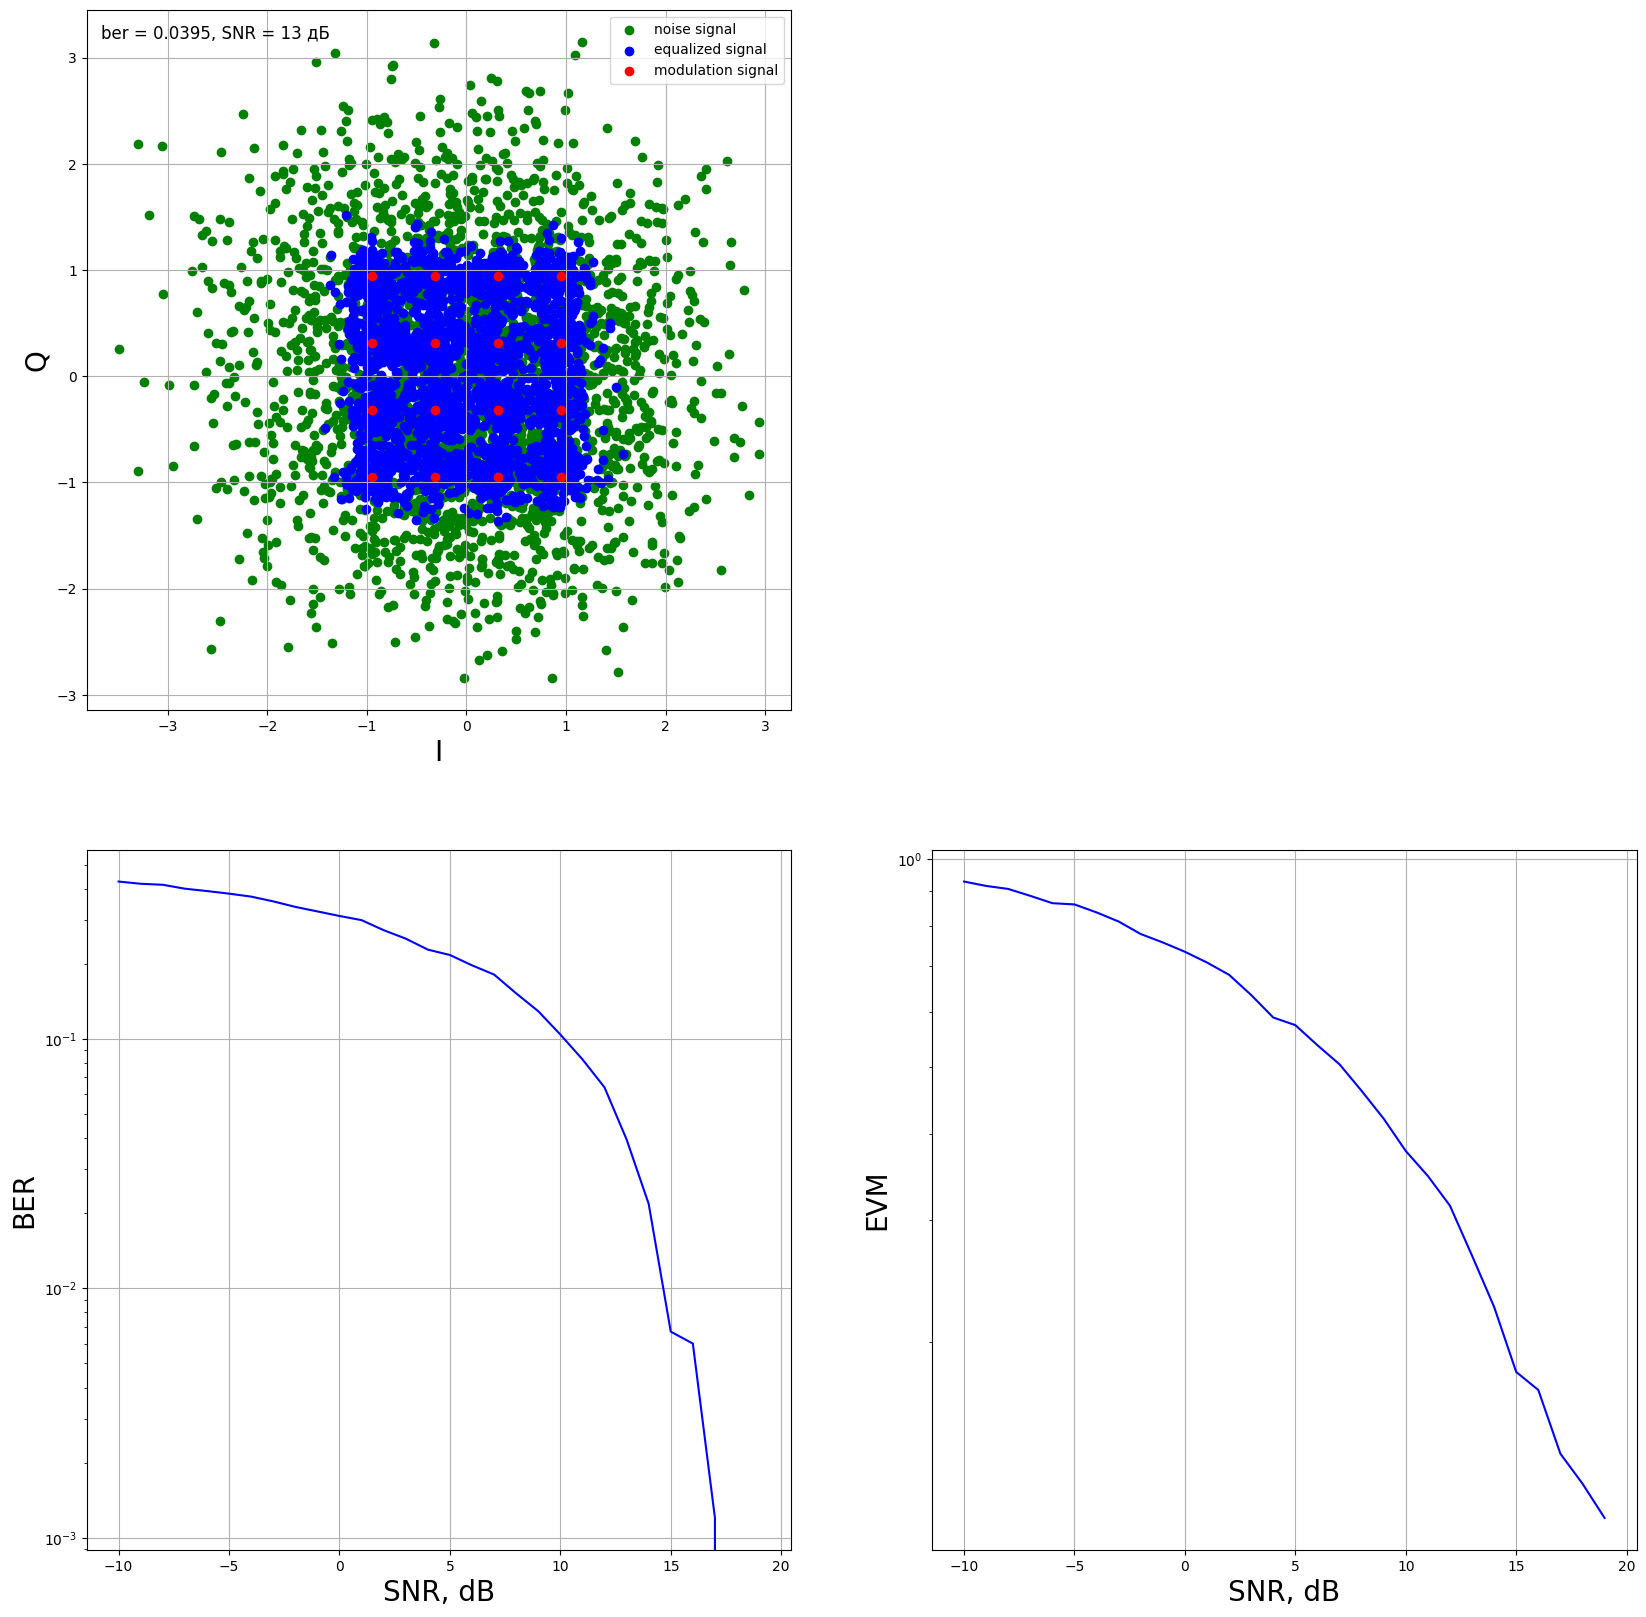

In [166]:
input_bits = np.random.randint(0, 2, size=10000)
input_signal = modem.modulate(input_bits) / np.sqrt(modem.Es)

SNR_arr = np.arange(-10, 20, 1)
ber_arr = []
evm_arr = []
L=10
h = impulse_response(L)
D=10
fig = None
for SNR in SNR_arr:
    D_noise = 10**(-SNR/10)

    w_ff, w_fb = weights_dfe(ir=h,
                             noise_variance=D_noise)

    output_signal = apply_multipath_propagation(signal=input_signal,
                                                ir=h,
                                                noise_variance=D_noise)

    I_hat, y = apply_dfe_equalizer(signal=output_signal,
                                   weights_feedforward=w_ff,
                                   weights_feedback=w_fb,
                                   impulse_response_length=L,
                                   delay=D)

    evm_arr.append(compute_evm(clear_signal=input_signal, equalized_signal=y, delay=D))

    output_bits = modem.demodulate(I_hat*np.sqrt(modem.Es), demod_type='hard')
    ber = compute_ber(clear_bits=input_bits, equalized_bits=output_bits)
    ber_arr.append(ber)

    if SNR == 13:
        fig = plot_constellation(noise_signal=output_signal,
                                 equalized_signal=y,
                                 bit_error_rate=ber,
                                 signal_noise_ratio=SNR)

if fig is not None:
    ax2 = fig.add_subplot(223)
    ax2.semilogy(SNR_arr, ber_arr, color='blue')
    ax2.set_xlabel(r'SNR, dB', fontsize=20)
    ax2.set_ylabel(r'BER', fontsize=20)
    ax2.grid()

    ax3 = fig.add_subplot(224)
    ax3.semilogy(SNR_arr, evm_arr, color='blue')
    ax3.set_xlabel(r'SNR, dB', fontsize=20)
    ax3.set_ylabel(r'EVM', fontsize=20)
    ax3.grid()

plt.show()